# Working with GeoPackage tiles

`gpkg_tiles` presents image tiles as Pillow images and gridded coverages as NumPy arrays. For either kind of layer, the workflow is simply: open, read, create, and write.

Everything here uses the small GeoPackages included with this repository.

In [1]:
from pathlib import Path
import tempfile

import numpy as np
from PIL import ImageOps
from IPython.display import display

from gpkg_tiles import GpkgTiles

samples = Path("example_geopackages")
work = tempfile.TemporaryDirectory(prefix="gpkg_tiles_")
output = Path(work.name) / "example.gpkg"

## Image tiles

Opening a layer returns the appropriate implementation automatically. Image tiles are ordinary Pillow images, ready to display or transform.

In [2]:
source = GpkgTiles.open(
    samples / "small_world_jpg_png.gpkg",
    "small_world_jpg_png",
)

print("kind:", source.kind)
print("zooms:", source.zooms)
print("bounds:", source.bounds)
print("tile size:", (source.tile_width, source.tile_height))

kind: image
zooms: (0, 1)
bounds: (-180.0, -270.0, 280.8, 90.0)
tile size: (256, 200)


This sample contains one JPEG tile and one PNG tile. They are fetched by coordinate with `get()`.

JPEG PNG


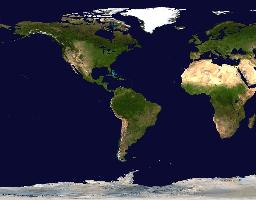

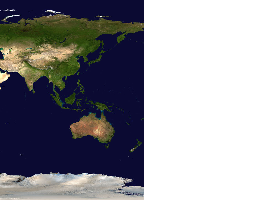

In [3]:
jpeg = source.get(source.base_zoom, 0, 0)
png = source.get(source.base_zoom, 1, 0)

print(jpeg.format, png.format)
display(jpeg, png)

WebP uses exactly the same API.

WEBP


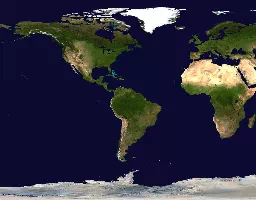

In [4]:
with GpkgTiles.open(samples / "small_world_webp.gpkg", "small_world_webp") as webp_layer:
    webp = webp_layer.get(webp_layer.base_zoom, 0, 0)
    print(webp.format)
    display(webp)

A tile pyramid can contain several zoom levels. `tiles("all")` reads all of them.

In [5]:
with GpkgTiles.open(samples / "small_world_png_with_ovr.gpkg", "small_world_png_with_ovr") as png_layer:
    print("zooms:", png_layer.zooms)
    print("tiles:", [tile for tile in png_layer.tiles("all")])

zooms: (0, 1)
tiles: [ImageTile(z=1, x=0, y=0, data=<PIL.Image.Image image mode=RGB size=256x200 at 0x10D32BFD0>), ImageTile(z=1, x=1, y=0, data=<PIL.Image.Image image mode=RGBA size=256x200 at 0x10CBE29E0>), ImageTile(z=0, x=0, y=0, data=<PIL.Image.Image image mode=RGBA size=256x200 at 0x107732860>)]


### Create an image layer

A new layer needs a tile grid. `like=source` copies the grid, bounds, CRS, and zoom levels—but not the tiles. The context manager commits on success and closes the layer.

In [6]:
with GpkgTiles.create(output, "blue_and_gold", like=source) as images:
    gray = jpeg.convert("L")
    recolored = ImageOps.colorize(gray, "#14213d", "#fca311")

    images.put(images.base_zoom, 0, 0, recolored)
    images.build_overviews(resampling="average")

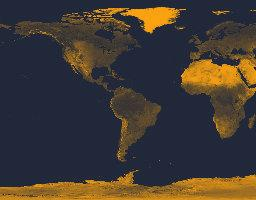

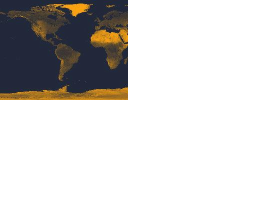

In [7]:
with GpkgTiles.open(output, "blue_and_gold") as images:
    display(images.get(images.base_zoom, 0, 0))
    display(images.get(0, 0, 0))

## Coverage tiles

A coverage tile is a two-dimensional NumPy array. Its shape must match the tile grid.

With `dtype=np.uint16`, integer values are stored in a 16-bit PNG. Setting `scale=1` and `offset=0` keeps integer values exact. Here `65535` is reserved for missing data, leaving `0` through `65534` for measurements.

In [8]:
elevation = GpkgTiles.create(
    output, "elevation", like=source, kind="coverage",
    dtype=np.uint16, data_null=65535,
    scale=1, offset=0, precision=1,
    uom="m", field_name="elevation",
    quantity_definition="Height above the reference surface",
)

In [9]:
shape = (elevation.tile_height, elevation.tile_width)
elevation_tile = np.ma.array(np.full(shape, 120, dtype=np.uint16), mask=False)
elevation_tile[50:150, 50:200] = 240
elevation_tile.mask[:20, :20] = True

elevation_tile

masked_array(
  data=[[--, --, --, ..., 120, 120, 120],
        [--, --, --, ..., 120, 120, 120],
        [--, --, --, ..., 120, 120, 120],
        ...,
        [120, 120, 120, ..., 120, 120, 120],
        [120, 120, 120, ..., 120, 120, 120],
        [120, 120, 120, ..., 120, 120, 120]],
  mask=[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
  fill_value=np.uint64(999999),
  dtype=uint16)

In [10]:
elevation.put(elevation.base_zoom, 0, 0, elevation_tile)
elevation.commit()

stored_elevation = elevation.get(elevation.base_zoom, 0, 0)
stored_elevation

masked_array(
  data=[[--, --, --, ..., 120, 120, 120],
        [--, --, --, ..., 120, 120, 120],
        [--, --, --, ..., 120, 120, 120],
        ...,
        [120, 120, 120, ..., 120, 120, 120],
        [120, 120, 120, ..., 120, 120, 120],
        [120, 120, 120, ..., 120, 120, 120]],
  mask=[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
  fill_value=np.uint64(999999),
  dtype=uint16)

Because the scale and offset are both identity values, the data is stored and returned as UInt16—matching GDAL. A coverage that uses scale or offset to represent fractional values is returned as Float32 instead.

In [11]:
print("returned dtype:", stored_elevation.dtype)
print("layer dtype:", elevation.dtype)

returned dtype: uint16
layer dtype: uint16


### Float32 coverage

Use Float32 when values should be stored directly with fractional precision. Float coverages use TIFF tiles. A mask or `NaN` marks missing cells when `data_null` is configured.

In [12]:
temperature_tile = np.full(shape, 18.5, dtype=np.float32)
temperature_tile[50:150, 50:200] = 22.25
temperature_tile[:20, :20] = np.nan

temperature_tile

array([[ nan,  nan,  nan, ..., 18.5, 18.5, 18.5],
       [ nan,  nan,  nan, ..., 18.5, 18.5, 18.5],
       [ nan,  nan,  nan, ..., 18.5, 18.5, 18.5],
       ...,
       [18.5, 18.5, 18.5, ..., 18.5, 18.5, 18.5],
       [18.5, 18.5, 18.5, ..., 18.5, 18.5, 18.5],
       [18.5, 18.5, 18.5, ..., 18.5, 18.5, 18.5]],
      shape=(200, 256), dtype=float32)

In [13]:
with GpkgTiles.create(
    output, "temperature", like=elevation,
    dtype=np.float32, data_null=-9999.0,
    scale=1, offset=0, precision=None,
    uom="°C", field_name="temperature",
    quantity_definition="Air temperature",
) as temperature:
    temperature.put(temperature.base_zoom, 0, 0, temperature_tile)

In [14]:
with GpkgTiles.open(output, "temperature") as temperature:
    stored_temperature = temperature.get(temperature.base_zoom, 0, 0)

stored_temperature

masked_array(
  data=[[--, --, --, ..., 18.5, 18.5, 18.5],
        [--, --, --, ..., 18.5, 18.5, 18.5],
        [--, --, --, ..., 18.5, 18.5, 18.5],
        ...,
        [18.5, 18.5, 18.5, ..., 18.5, 18.5, 18.5],
        [18.5, 18.5, 18.5, ..., 18.5, 18.5, 18.5],
        [18.5, 18.5, 18.5, ..., 18.5, 18.5, 18.5]],
  mask=[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
  fill_value=np.float64(1e+20),
  dtype=float32)

## The complete pattern

```python
with GpkgTiles.open(path, table) as source:
    with GpkgTiles.create(result, new_table, like=source) as destination:
        destination.put(z, x, y, transform(source.get(z, x, y)))
```

Use `get(z, x, y)` for one tile, iterate over a layer for its base-level tiles, and use `tiles("all")` for the whole pyramid. `build_overviews()` fills coarser levels. Context managers commit, roll back after an exception, and close the file.

In [15]:
elevation.close()
source.close()
work.cleanup()